# Тестовая сборка Transformer Encoder на тикере ROSN

In [1]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ----------------------- Настройки и константы -----------------------
SEQ_LEN = 15
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
EPOCHS = 60
LR = 0.00262
D_MODEL = 32
N_HEADS = 4
N_LAYERS = 2
D_FF = 384
DROPOUT = 0.09031434953930437
TICKER = "ROSN"
PAGE_LIMIT = 100
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------- Функция для загрузки данных -----------------------
def fetch_moex_data(security, engine, market, board, start, end):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_rows = []
    offset = 0
    while True:
        params = {"from": start, "till": end, "start": offset, "limit": PAGE_LIMIT}
        resp = requests.get(base_url, params=params)
        if resp.status_code != 200:
            raise RuntimeError(f"MOEX HTTP {resp.status_code}")
        data = resp.json().get("history", {})
        cols = data.get("columns", [])
        rows = data.get("data", [])
        if not rows:
            break
        all_rows.extend(rows)
        if len(rows) < PAGE_LIMIT:
            break
        offset += PAGE_LIMIT
    df = pd.DataFrame(all_rows, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.sort_values('TRADEDATE').reset_index(drop=True)

In [2]:
# ----------------------- Вычисление индикаторов -----------------------
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_sma(series, window=14): return series.rolling(window).mean()

def compute_log_returns(series, window=1): return np.log(series).diff(window)

def compute_volatility(series, window=14): return compute_log_returns(series).rolling(window).std()

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    sig_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, sig_line, macd_line - sig_line

def compute_bollinger_bands(series, window=20, num_std=2):
    sma = series.rolling(window).mean()
    std = series.rolling(window).std()
    return sma + std*num_std, sma - std*num_std

def compute_atr(df, high_col, low_col, close_col, window=14):
    hi, lo, cl = df[high_col], df[low_col], df[close_col]
    tr = pd.concat([hi-lo, (hi-cl.shift()).abs(), (lo-cl.shift()).abs()], axis=1).max(axis=1)
    return tr.rolling(window).mean()

# ----------------------- Подготовка данных для обучения -----------------------
def prepare_df(ticker):
    start, end = "2010-01-01", datetime.today().strftime("%Y-%m-%d")
    df = fetch_moex_data(ticker, 'stock','shares','TQBR', start, end)
    df = df.rename(columns={'OPEN':'OPEN','HIGH':'HIGH','LOW':'LOW','CLOSE':'CLOSE','VOLUME':'VOLUME'})
    df = df[['TRADEDATE','OPEN','HIGH','LOW','CLOSE','VOLUME']].dropna().reset_index(drop=True)
    close = df['CLOSE']
    df['log_ret'] = compute_log_returns(close)
    df['rsi_14'] = compute_rsi(close)
    df['sma_14'] = compute_sma(close)
    df['vol_14'] = compute_volatility(close)
    macd, sig, hist = compute_macd(close)
    df['macd'], df['macd_sig'], df['macd_hist'] = macd, sig, hist
    bb_up, bb_low = compute_bollinger_bands(close)
    df['bb_up'], df['bb_low'] = bb_up, bb_low
    df['atr_14'] = compute_atr(df, 'HIGH','LOW','CLOSE')
    df.dropna(inplace=True)
    return df

def create_sequences(values, seq_len):
    X,y = [],[]
    for i in range(len(values)-seq_len):
        X.append(values[i:i+seq_len]); y.append(values[i+seq_len,2])
    return np.asarray(X), np.asarray(y)

def get_datasets(df):
    feats = [c for c in df.columns if c!='TRADEDATE']
    data = df[feats].values
    scaler = RobustScaler().fit(data)
    data_s = scaler.transform(data)
    X, y = create_sequences(data_s, SEQ_LEN)
    split = int(len(X)*TRAIN_RATIO)
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]
    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
    test_ds  = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.float32))
    test_dates = df['TRADEDATE'].values[SEQ_LEN+split:]
    return train_ds, test_ds, scaler, test_dates

/Users/nasdorm/.pyenv/versions/3.11.9/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/60 | Train Loss: 0.0286 | Val Loss: 0.0099
Epoch 2/60 | Train Loss: 0.0062 | Val Loss: 0.0023
Epoch 3/60 | Train Loss: 0.0041 | Val Loss: 0.0027
Epoch 4/60 | Train Loss: 0.0044 | Val Loss: 0.0041
Epoch 5/60 | Train Loss: 0.0036 | Val Loss: 0.0025
Epoch 6/60 | Train Loss: 0.0030 | Val Loss: 0.0065
Epoch 7/60 | Train Loss: 0.0025 | Val Loss: 0.0039
Epoch 8/60 | Train Loss: 0.0021 | Val Loss: 0.0019
Epoch 9/60 | Train Loss: 0.0019 | Val Loss: 0.0121
Epoch 10/60 | Train Loss: 0.0025 | Val Loss: 0.0029
Epoch 11/60 | Train Loss: 0.0018 | Val Loss: 0.0024
Epoch 12/60 | Train Loss: 0.0022 | Val Loss: 0.0013
Epoch 13/60 | Train Loss: 0.0017 | Val Loss: 0.0025
Epoch 14/60 | Train Loss: 0.0023 | Val Loss: 0.0015
Epoch 15/60 | Train Loss: 0.0017 | Val Loss: 0.0013
Epoch 16/60 | Train Loss: 0.0018 | Val Loss: 0.0017
Epoch 17/60 | Train Loss: 0.0023 | Val Loss: 0.0017
Epoch 18/60 | Train Loss: 0.0018 | Val Loss: 0.0014
Epoch 19/60 | Train Loss: 0.0014 | Val Loss: 0.0015
Epoch 20/60 | Train L

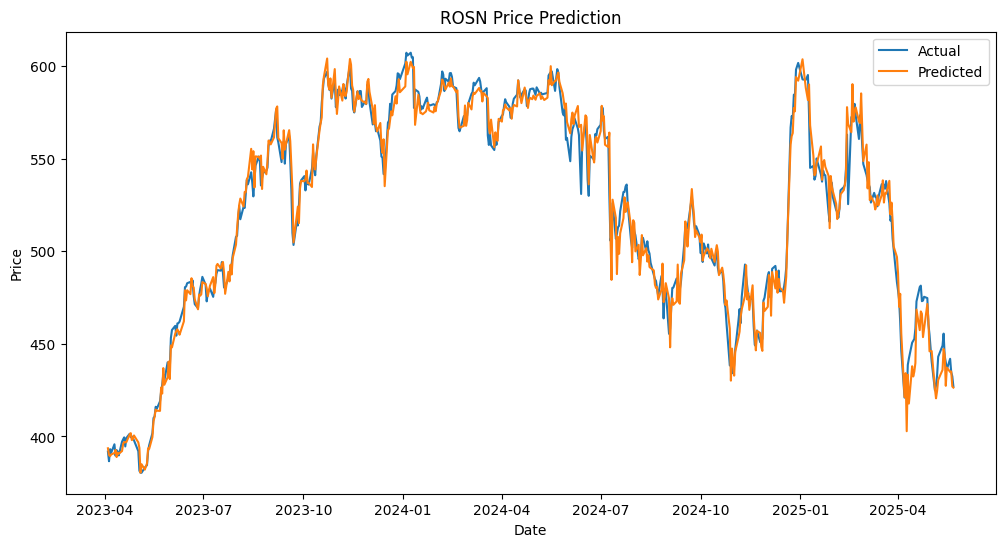

In [3]:
# ----------------------- Transformer модель -----------------------
class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.input_proj = nn.Linear(num_features, D_MODEL)
        self.pos_emb = nn.Parameter(torch.randn(SEQ_LEN, D_MODEL))
        layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=N_HEADS, dim_feedforward=D_FF, dropout=DROPOUT)
        self.transformer = nn.TransformerEncoder(layer, num_layers=N_LAYERS)
        self.decoder = nn.Sequential(nn.Linear(D_MODEL,D_FF), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(D_FF,1))
    def forward(self, x):
        x = self.input_proj(x) + self.pos_emb.unsqueeze(0)
        x = x.permute(1,0,2)
        x = self.transformer(x)
        return self.decoder(x[-1]).squeeze()

# ----------------------- Обучение и Валидация -----------------------
def train_and_eval():
    df = prepare_df(TICKER)
    train_ds, test_ds, scaler, test_dates = get_datasets(df)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)
    model = TimeSeriesTransformer(train_ds.tensors[0].shape[-1])
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); model.to(device)
    opt = optim.AdamW(model.parameters(), lr=LR); crit = nn.HuberLoss()
    best_val = float('inf')
    for epoch in range(1,EPOCHS+1):
        model.train(); tl=[]
        for Xb,yb in train_loader:
            Xb,yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); loss=crit(model(Xb), yb); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1); opt.step(); tl.append(loss.item())
        model.eval(); vl=[]
        with torch.no_grad():
            for Xv,yv in test_loader:
                Xv,yv = Xv.to(device), yv.to(device); vl.append(crit(model(Xv), yv).item())
        tr, vr = np.mean(tl), np.mean(vl)
        print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr:.4f} | Val Loss: {vr:.4f}")
        if vr<best_val: best_val=vr; torch.save(model.state_dict(),f"{TICKER}_best.pth")
    print("Training complete. Best Val Loss:", best_val)
    # Прогноз
    model.load_state_dict(torch.load(f"{TICKER}_best.pth")); model.eval()
    preds, acts = [],[]
    with torch.no_grad():
        for Xb,yb in test_loader:
            preds.extend(model(Xb.to(device)).cpu().numpy()); acts.extend(yb.numpy())
    preds, acts = np.array(preds), np.array(acts)
    # Обратное маштабирование
    dummy = np.zeros((len(preds), scaler.scale_.shape[0]))
    close_idx = df.columns.get_loc('CLOSE')-1
    dummy[:,close_idx]=preds; inv_p = scaler.inverse_transform(dummy)[:,close_idx]
    dummy[:,close_idx]=acts; inv_a = scaler.inverse_transform(dummy)[:,close_idx]
    # Метрики
    mse=mean_squared_error(inv_a,inv_p); rmse=np.sqrt(mse)
    mae=mean_absolute_error(inv_a,inv_p); max_err=np.max(np.abs(inv_a-inv_p))
    mape=np.mean(np.abs((inv_a-inv_p)/inv_a))*100
    print(f"Metrics for {TICKER}: MSE:{mse:.3f}, RMSE:{rmse:.3f}, MAE:{mae:.3f}, MAPE:{mape:.2f}%, MaxErr:{max_err:.3f}")
    # График
    plt.figure(figsize=(12,6)); plt.plot(test_dates, inv_a, label='Actual'); plt.plot(test_dates, inv_p, label='Predicted')
    plt.title(f"{TICKER} Price Prediction"); plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.show()
    os.makedirs("models", exist_ok=True)
    model_path = os.path.join("models", "GAZP_model.pth")
    scaler_X_path = os.path.join("models", "GAZP_scaler_X.pkl")
    scaler_y_path = os.path.join("models", "GAZP_scaler_y.pkl")

if __name__=='__main__':
    train_and_eval()
